In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("C:\\Users\\Asus\\OneDrive\\Desktop\\power shheets\\gene_expression.csv")
df.head()

,Gene One,Gene Two,Cancer Present
0,4.3,3.9,1
1,2.5,6.3,0
2,5.7,3.9,1
3,6.1,6.2,0
4,7.4,3.4,1


- EDA

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gene One        3000 non-null   float64
 1   Gene Two        3000 non-null   float64
 2   Cancer Present  3000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 70.4 KB


In [4]:
df.describe()

,Gene One,Gene Two,Cancer Present
count,3000.000000,3000.000000,3000.000000
mean,5.600133,5.410467,0.500000
std,1.828388,1.729081,0.500083
min,1.000000,1.000000,0.000000
25%,4.300000,4.000000,0.000000
50%,5.600000,5.400000,0.500000
75%,6.900000,6.700000,1.000000
max,10.000000,10.000000,1.000000


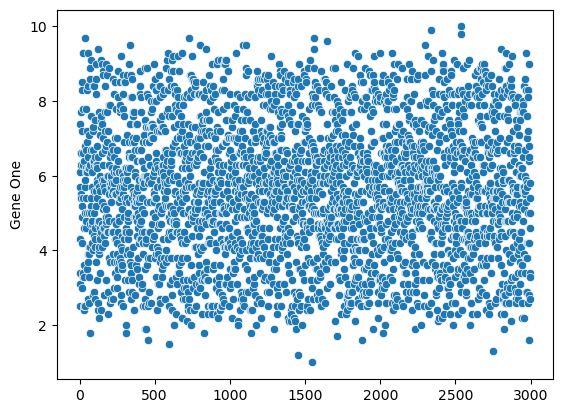

In [5]:
sns.scatterplot(data=df['Gene One'])
plt.show()

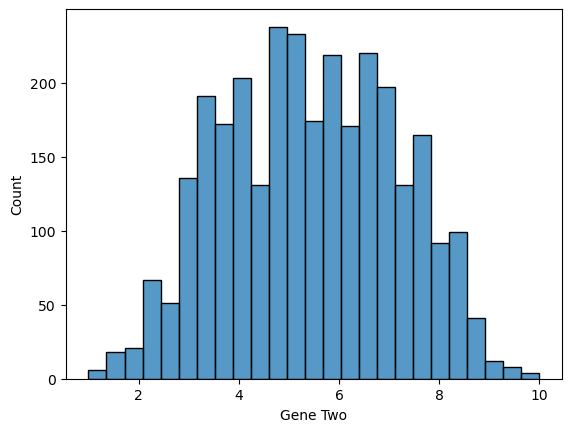

In [6]:
sns.histplot(data=df['Gene Two'])
plt.show()

In [7]:
df['Gene One'].value_counts()

Gene One
5.6     75
5.7     70
5.3     68
5.0     66
5.4     64
        ..
1.7      1
9.9      1
10.0     1
9.8      1
1.3      1
Name: count, Length: 89, dtype: int64

In [8]:
df['Gene Two'].value_counts()

Gene Two
4.7     74
4.6     70
6.2     65
5.3     63
6.6     63
        ..
9.8      2
9.6      2
9.5      1
9.7      1
10.0     1
Name: count, Length: 88, dtype: int64

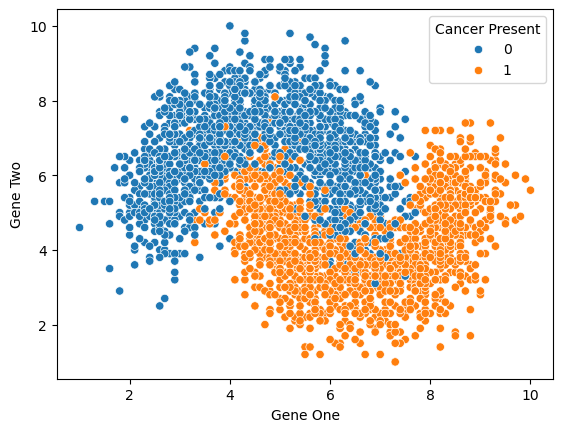

In [9]:
sns.scatterplot(x='Gene One',y='Gene Two',hue='Cancer Present',data=df)
plt.show()

In [10]:
df.isnull().sum()     # theree is no any missing values

Gene One          0
Gene Two          0
Cancer Present    0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(862)

In [12]:
df[df.duplicated()]    #There is chance of duplicate value so wwe retrain them

,Gene One,Gene Two,Cancer Present
38,5.0,5.3,0
69,6.3,7.7,0
160,4.4,5.1,1
163,5.7,7.2,0
193,6.3,6.6,0
...,...,...,...
2985,4.2,6.4,0
2987,6.4,5.5,0
2988,9.0,4.7,1
2992,2.8,7.1,0


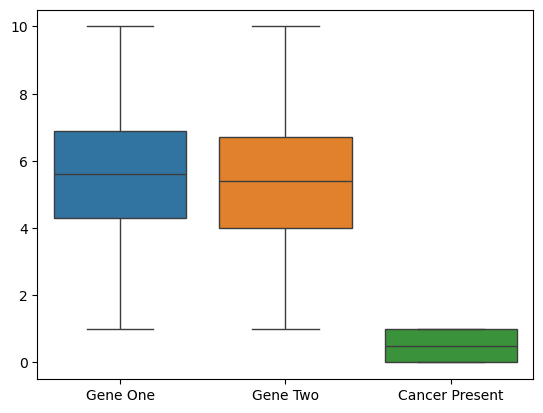

In [13]:
sns.boxplot(data=df)         #There is no outliers
plt.show()

- X and y

In [14]:
X=df.drop('Cancer Present',axis=1)
y=df['Cancer Present']

- train test split

In [15]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

- Scaling

In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

- Modeling

In [17]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [18]:
ypred_train=knn.predict(X_train)
ypred_test=knn.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score
print("accuracy score:",accuracy_score(ypred_train,y_train))
print("accuracy_score:",accuracy_score(ypred_test,y_test))

accuracy score: 0.945
accuracy_score: 0.92


In [20]:
from sklearn.model_selection import cross_val_score
print("cross_val_score:",cross_val_score(knn,X,y,cv=5).mean())

cross_val_score: 0.9266666666666665


- Choosing best K value

- Hyper parameter tuning for KNN Classifier

In [21]:
from sklearn.model_selection import GridSearchCV

In [22]:
estimator=KNeighborsClassifier()
param_grid={'n_neighbors':list(range(1,31)),'p':[1,2]}
full_cv_classifier=GridSearchCV(estimator,param_grid,cv=5,scoring='accuracy')

In [23]:
full_cv_classifier.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                         13, 14, 15, 16, 17, 18, 19, 20, 21, 22,
                                         23, 24, 25, 26, 27, 28, 29, 30],
                         'p': [1, 2]},
             scoring='accuracy')

In [24]:
full_cv_classifier.best_params_

{'n_neighbors': 20, 'p': 2}

In [25]:
knn=KNeighborsClassifier(n_neighbors=20,p=2)
knn.fit(X_train,y_train)

KNeighborsClassifier(n_neighbors=20)

In [26]:
from sklearn.metrics import accuracy_score
print("accuracy score:",accuracy_score(ypred_train,y_train))
print("accuracy_score:",accuracy_score(ypred_test,y_test))

accuracy score: 0.945
accuracy_score: 0.92


In [27]:
from sklearn.model_selection import cross_val_score
print("cross_val_score:",cross_val_score(knn,X,y,cv=5).mean())

cross_val_score: 0.9336666666666666


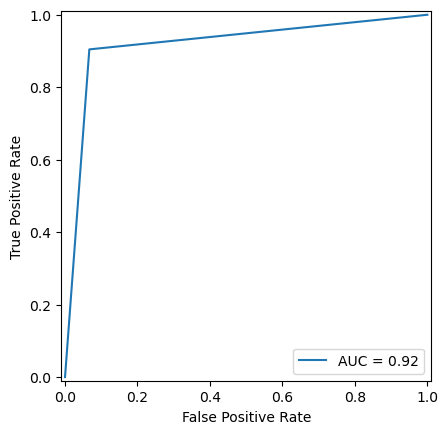

In [28]:
from sklearn.metrics import roc_curve,auc,RocCurveDisplay
fpr,tpr,threshold=roc_curve(y_test,ypred_test)
roc_auc=auc(fpr,tpr)
RocCurveDisplay(fpr=fpr,tpr=tpr,roc_auc=roc_auc).plot()
plt.show()